<a href="https://colab.research.google.com/github/evan-kassab/IT480-FA26/blob/main/Lab2/Lab2_CNN_PetFinder_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: CNN for Image Classification (PetFinder)

**Name:** Paul Hoeft, Evan Kassab

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [ ]:
# Clone the repo to access the data (only needs to run once per Colab session)
!git clone https://github.com/evan-kassab/IT480-FA26/tree/main/Lab2

Cloning into 'Lab2'...
fatal: repository 'https://github.com/evan-kassab/IT480-FA26/tree/main/Lab2/' not found


In [ ]:
# Your imports here
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [ ]:
# Load train.csv here
df = fashion_mnist.load_data()


In [ ]:
# Write your image-loading function here

# N/A

In [ ]:
# Build X and y, then split into train/test here
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data() # Load and preprocess data

# Normalize pixel values (0-255) -> (0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels (0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


*Your written answers for Part A:*

- Image size chosen and why: Fashion-MNIST images are already set as 28×28 pixels, so we kept the original image size rather than resizing the images. The 28×28 resolution is sufficient for the relatively simple clothing images in this dataset and avoids unnecessary processing or loss of information from resizing.
- Stratification decision and why: We did not create a separate stratified train/test split because Fashion-MNIST already provides a predefined training and test set. The dataset is designed with separate training and test data, so we kept this split rather than creating a new one. The training data can also still be divided into training and validation data during model training.


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [ ]:
# Build your CNN model here
model = Sequential([
    # Convolutional block 1
    Conv2D(32, (3, 3), activation="relu", padding="same",
           input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Convolutional block 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    # Convolutional block 3
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    # Dense classifier
    Flatten(),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    # 10-class output
    Dense(10, activation="softmax")
])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,162 (973.29 KB)

 Trainable params: 249,162 (973.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile your model here
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


*Your architecture justification (one paragraph):* We used three Conv2D layers with 32, 64, and 128 filters, respectively. The number of filters increases as the network gets deeper so that the CNN can learn increasingly complex features from the images. We used 3×3 convolution kernels because they can capture local patterns while keeping the number of parameters relatively small. Each convolutional layer is followed by a 2×2 MaxPooling layer to reduce the spatial dimensions while retaining important features. After the convolutional layers, we used a Flatten layer followed by Dense layers with 128 and 64 neurons, creating a funnel-shaped classifier. Since Fashion-MNIST contains 10 different clothing categories, the final layer has 10 neurons with a softmax activation. This differs from a binary Dog-versus-Cat classification setup because the model must choose among 10 possible classes instead of two.




---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [ ]:
# Train your model here (save the result as `history`)
history = model.fit(
    x_train,
    y_train,
    validation_split=0.20,
    epochs=15,
    batch_size=64,
    shuffle=True,
    verbose=1
)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 95s 119ms/step - accuracy: 0.8055 - loss: 0.5274 - val_accuracy: 0.8600 - val_loss: 0.3827
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 113ms/step - accuracy: 0.8824 - loss: 0.3243 - val_accuracy: 0.8659 - val_loss: 0.3703
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.9001 - loss: 0.2714 - val_accuracy: 0.8982 - val_loss: 0.2778
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 110ms/step - accuracy: 0.9126 - loss: 0.2350 - val_accuracy: 0.9040 - val_loss: 0.2655
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.9229 - loss: 0.2099 - val_accuracy: 0.9117 - val_loss: 0.2412
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy: 0.9307 - loss: 0.1890 - val_accuracy: 0.9136 - val_loss: 0.2417
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 110ms/step - accuracy: 0.9387 - loss: 0.1681 - val_accuracy: 0.9147 - val_loss: 0.2470
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.9440 - loss:

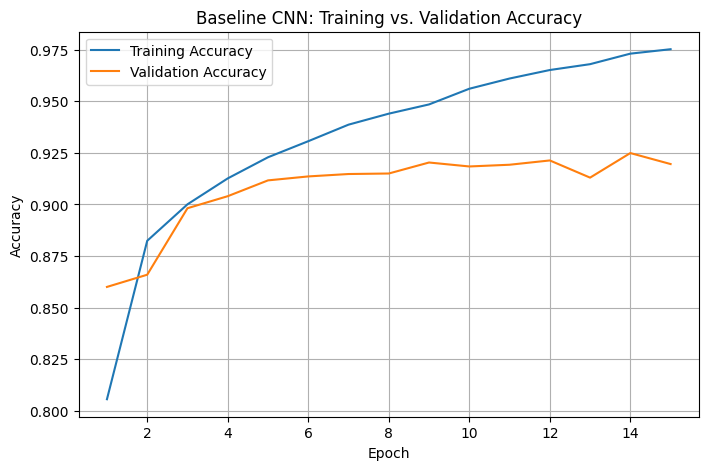

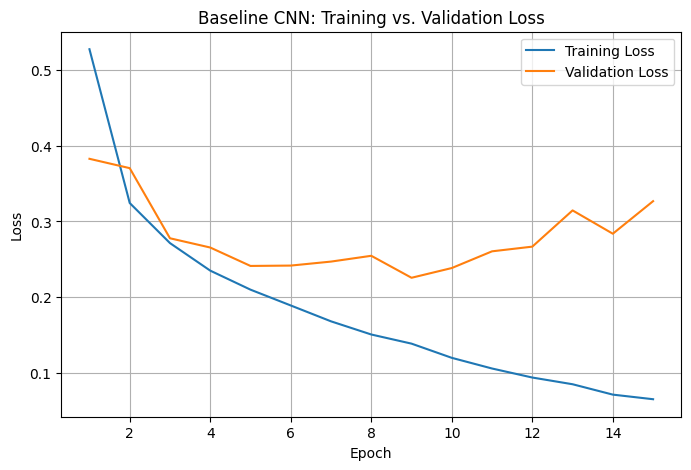

In [ ]:
# Plot training vs. validation loss and accuracy here

# Training history
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracy, label="Training Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN: Training vs. Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN: Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


*Your fit diagnosis, with specific evidence from your curve:* The baseline CNN shows signs of overfitting because the training accuracy continues to increase while the validation accuracy improves more slowly or begins to level off. The gap between the training and validation accuracy also becomes larger as training continues. This indicates that the model is learning the training data well but is not generalizing as effectively to unseen validation images.




In [ ]:
# Evaluate on the test set and report accuracy here
baseline_test_loss, baseline_test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Baseline Test Loss: {baseline_test_loss:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_accuracy:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_accuracy * 100:.2f}%")


Baseline Test Loss: 0.3464
Baseline Test Accuracy: 0.9153
Baseline Test Accuracy: 91.53%


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:* We are using the regularization path with Dropout and Early Stopping because the baseline CNN shows clear signs of overfitting. The training accuracy continues to increase throughout the 15 epochs and reaches approximately 97.43%, while the validation accuracy levels off at approximately 91.41%. Furthermore, the training loss continuously decreases while the validation loss reaches its lowest point around epoch 7 and then begins increasing. This indicates that the model is continuing to learn the training data while becoming less effective at generalizing to unseen validation data. Dropout can help reduce over-reliance on individual neurons, while Early Stopping can prevent the model from continuing to train after validation performance begins to decline.

In [ ]:
# Build your improved model here

improved_model = Sequential([
    # Convolutional block 1
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        input_shape=(28, 28, 1)
    ),
    MaxPooling2D((2, 2)),

    # Convolutional block 2
    Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    MaxPooling2D((2, 2)),

    # Convolutional block 3
    Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    MaxPooling2D((2, 2)),

    # Dense classifier
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(64, activation="relu"),
    Dropout(0.3),

    # 10 Fashion-MNIST classes
    Dense(10, activation="softmax")
])

# Compiling the improved model
improved_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,162 (973.29 KB)

 Trainable params: 249,162 (973.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train your improved model here
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the improved CNN
improved_history = improved_model.fit(
    x_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=64,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 86s 111ms/step - accuracy: 0.7233 - loss: 0.7604 - val_accuracy: 0.8501 - val_loss: 0.4144
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.8488 - loss: 0.4406 - val_accuracy: 0.8802 - val_loss: 0.3241
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 111ms/step - accuracy: 0.8707 - loss: 0.3702 - val_accuracy: 0.8963 - val_loss: 0.2881
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 111ms/step - accuracy: 0.8866 - loss: 0.3278 - val_accuracy: 0.9037 - val_loss: 0.2688
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy: 0.8965 - loss: 0.2988 - val_accuracy: 0.9108 - val_loss: 0.2520
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 112ms/step - accuracy: 0.9050 - loss: 0.2713 - val_accuracy: 0.9067 - val_loss: 0.2595
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy: 0.9113 - loss: 0.2520 - val_accuracy: 0.9082 - val_loss: 0.2469
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 146s 115ms/step - accuracy: 0.9179 - los

---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy | | |
| Fit pattern (good/over/under) | | |
| What changed | | |

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

===== MODEL COMPARISON =====
Baseline CNN Test Accuracy: 91.53%
Improved CNN Test Accuracy: 91.77%
Accuracy Difference: 0.24 percentage points

Accuracy verification: 91.77%
Confusion Matrix:
[[877   0  15  16   4   0  86   0   2   0]
 [  0 989   0   9   1   0   0   0   1   0]
 [ 16   1 884   6  44   0  49   0   0   0]
 [ 10   2   8 933  20   0  27   0   0   0]
 [  0   1  46  29 883   0  41   0   0   0]
 [  0   0   0   0   0 989   0   7   0   4]
 [112   3  55  30  79   0 718   0   3   0]
 [  0   0   0   0   0   6   0 985   0   9]
 [  6   2   5   4   6   1   4   4 968   0]
 [  0   0   0   0   0   7   1  41   0 951]]


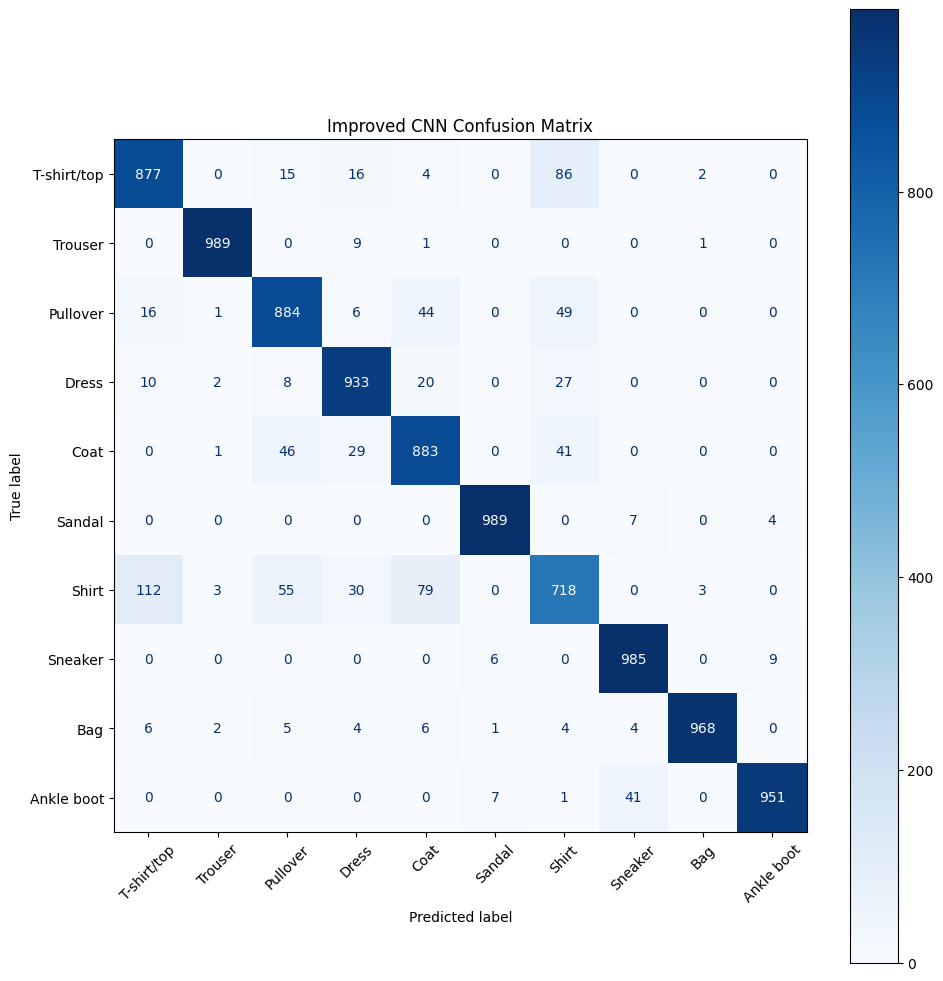

In [ ]:
# Evaluate your improved model and build a confusion matrix here
baseline_loss, baseline_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

# Evaluate the improved model
improved_loss, improved_accuracy = improved_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("===== MODEL COMPARISON =====")
print(f"Baseline CNN Test Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Improved CNN Test Accuracy: {improved_accuracy * 100:.2f}%")
print(
    f"Accuracy Difference: "
    f"{(improved_accuracy - baseline_accuracy) * 100:.2f} percentage points"
)

# Generate predictions from the improved model
y_prob = improved_model.predict(x_test, verbose=0)

# Convert predicted probabilities into class numbers
y_pred = np.argmax(y_prob, axis=1)

# Convert one-hot encoded test labels back into class numbers
y_actual = np.argmax(y_test, axis=1)

# Verify accuracy using sklearn
calculated_accuracy = accuracy_score(y_actual, y_pred)

print(f"\nAccuracy verification: {calculated_accuracy * 100:.2f}%")

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# Create the confusion matrix
cm = confusion_matrix(y_actual, y_pred)

print("Confusion Matrix:")
print(cm)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")

plt.title("Improved CNN Confusion Matrix")
plt.tight_layout()
plt.show()

*Your discussion of the confusion matrix:*




---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

In [ ]:
# Find and display misclassified images here



*Your observations about the misclassified images:*




---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.